# Rainfall Time Series Predection :
This Project aims to develop a Machine Learning model that accurately predicts rainfall for next one year using histrocial weather data and forecast the highest daily rainfall for given month.

# This notebook includes :
# Rainfall-Time Series Dataset
# EDA Part
# Advance Feature Engineering
# Model Building and Evulation
# Business Insights

# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#8b949e',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#30363d',
    'grid.alpha':       0.4,
    'axes.grid':        True,
    'font.family':      'DejaVu Sans',
})

C = {
    'bg':    '#0d1117', 'panel': '#161b22', 'blue':  '#1f6feb',
    'a1':    '#f78166', 'a2':    '#a5d6ff', 'a3':    '#7ee787',
    'a4':    '#ffa657', 'text':  '#e6edf3', 'sub':   '#8b949e',
    'grid':  '#30363d',
}

print('✅ Libraries imported successfully')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
import sklearn; print(f'   sklearn {sklearn.__version__}')

✅ Libraries imported successfully
   pandas  2.2.2
   numpy   2.0.2
   sklearn 1.6.1


# Data Loading & Merging

In [7]:
# Load all 3 datasets
total   = pd.read_csv(r"/content/rainfall-monthly-total.csv")
highest = pd.read_csv(r"/content/rainfall-monthly-highest-daily-total.csv")
days    = pd.read_csv(r"/content/rainfall-monthly-number-of-rain-days.csv")

print('Shape of each dataset:')
print(f'  Total Rainfall           : {total.shape}')
print(f'  Highest Daily Rainfall   : {highest.shape}')
print(f'  Number of Rain Days      : {days.shape}')

Shape of each dataset:
  Total Rainfall           : (462, 2)
  Highest Daily Rainfall   : (462, 2)
  Number of Rain Days      : (462, 2)


In [8]:
# ── Merge on 'month' column ───────────────────────────────────────────────────
df = total.merge(highest, on='month').merge(days, on='month')
df['date']      = pd.to_datetime(df['month'])
df              = df.sort_values('date').reset_index(drop=True)
df['year']      = df['date'].dt.year
df['month_num'] = df['date'].dt.month

print(f'Merged dataset shape : {df.shape}')
print(f'Date range           : {df["date"].min().strftime("%b %Y")} — {df["date"].max().strftime("%b %Y")}')
df.head(10)

Merged dataset shape : (462, 7)
Date range           : Jan 1982 — Jun 2020


,month,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days,date,year,month_num
0,1982-01,107.1,36.5,10,1982-01-01,1982,1
1,1982-02,27.8,9.4,5,1982-02-01,1982,2
2,1982-03,160.8,61.7,11,1982-03-01,1982,3
3,1982-04,157.0,45.1,14,1982-04-01,1982,4
4,1982-05,102.2,33.0,10,1982-05-01,1982,5
5,1982-06,59.5,20.6,8,1982-06-01,1982,6
6,1982-07,76.3,17.2,8,1982-07-01,1982,7
7,1982-08,169.5,57.7,11,1982-08-01,1982,8
8,1982-09,54.1,18.0,9,1982-09-01,1982,9
9,1982-10,39.3,10.0,10,1982-10-01,1982,10


In [10]:
# ── Missing values & basic info ───────────────────────────────────────────────
print('Missing values per column:')
print(df.isnull().sum())
print()
df[['total_rainfall','maximum_rainfall_in_a_day','no_of_rainy_days']].describe().round(2)

Missing values per column:
month                        0
total_rainfall               0
maximum_rainfall_in_a_day    0
no_of_rainy_days             0
date                         0
year                         0
month_num                    0
dtype: int64



,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days
count,462.00,462.00,462.00
mean,176.24,52.36,13.96
std,113.30,35.69,4.95
min,0.20,0.20,1.00
25%,89.02,30.62,11.00
50%,158.45,43.45,14.00
75%,237.95,63.15,18.00
max,765.90,216.20,27.00


# Exploratory Data Analysis ( EDA PART) :
Performed Exploratory Data Analysis (EDA) to understand rainfall patterns, trends, and seasonality in the dataset. Analyzed data distribution, detected outliers, and examined relationships between features using visualizations. Identified key insights such as skewness in rainfall values and seasonal variations to support effective feature engineering and model selection.

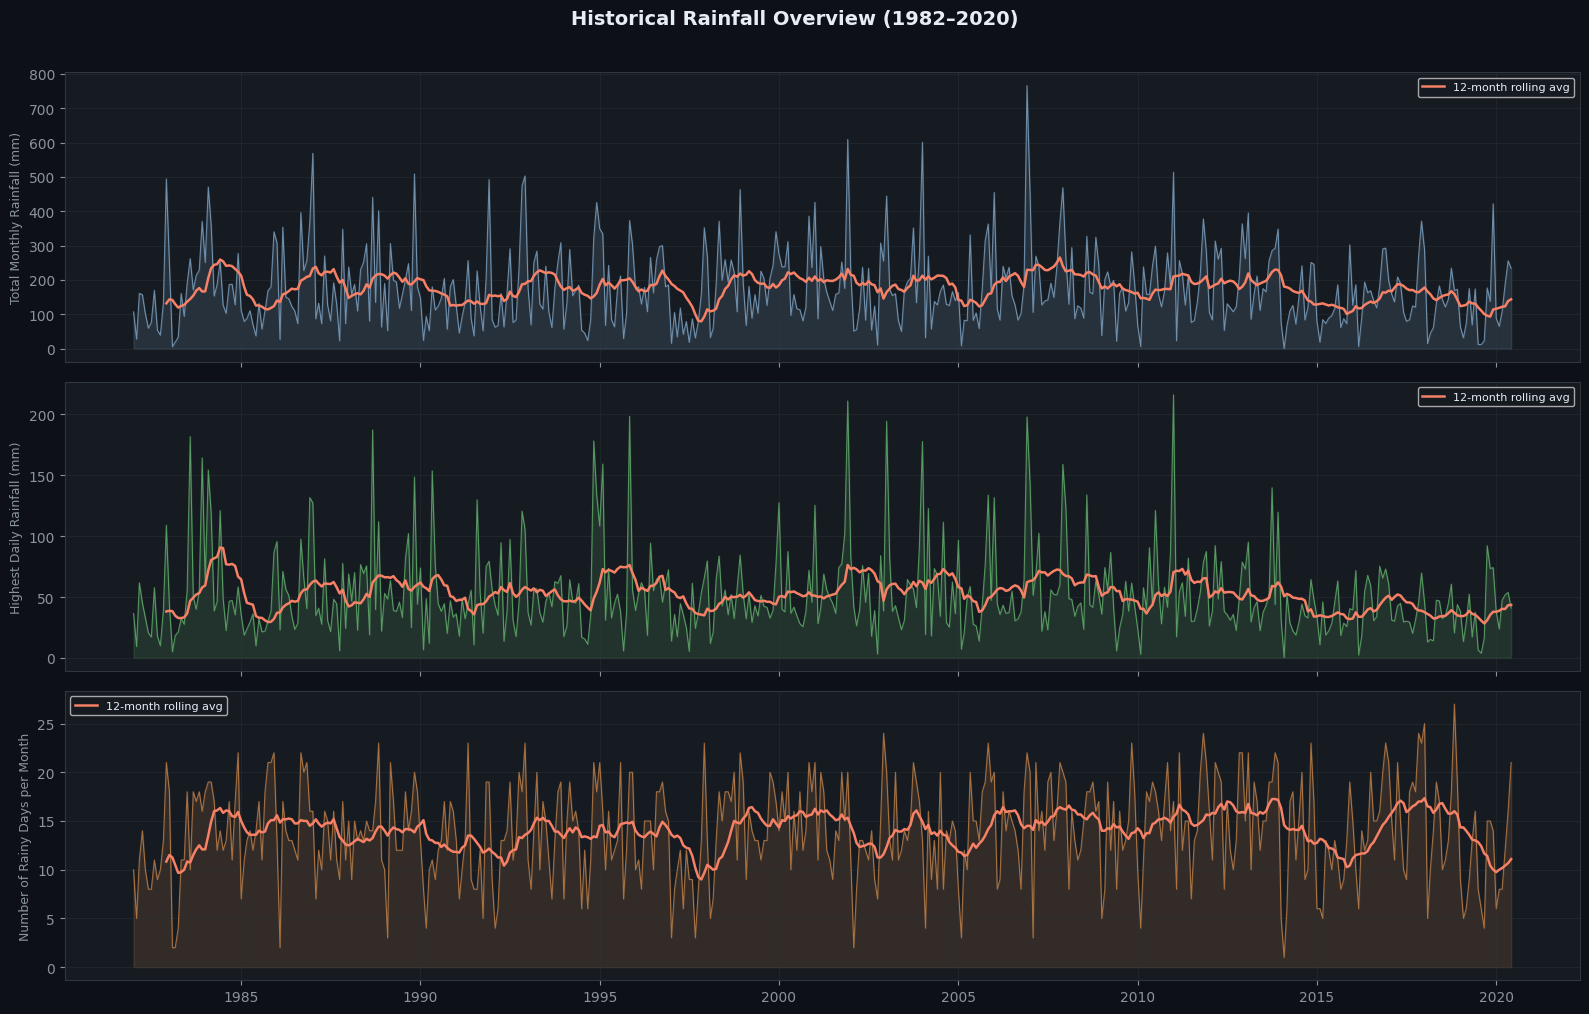

✅ Plot saved: 01_historical_overview.png


In [11]:
# ── Full historical time series ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10), facecolor=C['bg'], sharex=True)
fig.suptitle('Historical Rainfall Overview (1982–2020)', color=C['text'], fontsize=14, fontweight='bold', y=1.01)

series = [
    ('total_rainfall',              'Total Monthly Rainfall (mm)',       C['a2']),
    ('maximum_rainfall_in_a_day',   'Highest Daily Rainfall (mm)',       C['a3']),
    ('no_of_rainy_days',            'Number of Rainy Days per Month',    C['a4']),
]

for ax, (col, title, color) in zip(axes, series):
    ax.set_facecolor(C['panel'])
    ax.plot(df['date'], df[col], color=color, lw=0.8, alpha=0.55)
    ax.fill_between(df['date'], df[col], alpha=0.12, color=color)
    roll = df[col].rolling(12).mean()
    ax.plot(df['date'], roll, color=C['a1'], lw=1.8, label='12-month rolling avg')
    ax.set_ylabel(title, fontsize=9)
    ax.legend(fontsize=8, facecolor=C['panel'], labelcolor=C['text'])
    for sp in ax.spines.values(): sp.set_color(C['grid'])

plt.tight_layout()
plt.savefig('01_historical_overview.png', dpi=130, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('✅ Plot saved: 01_historical_overview.png')

# Insights from this graph :
#The data shows strong seasonal patterns with high variability and occasional extreme rainfall events, while the overall long-term trend remains stable.
 and presence of noise and spikes makes forecasting challenging, requiring feature engineering and advanced models.

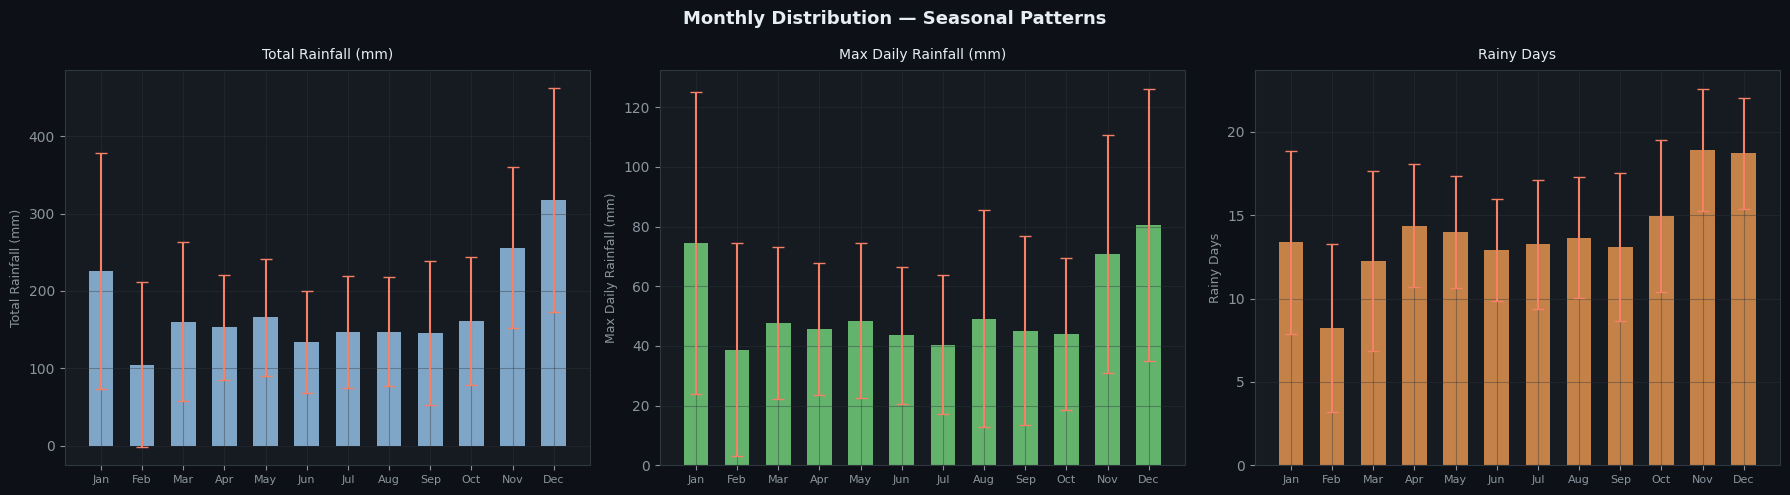

✅ Plot saved: 02_seasonal_patterns.png


In [12]:
# ── Seasonal (monthly) distribution ──────────────────────────────────────────
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']  # used for x-axis

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=C['bg'])      # 1 row, 3 column and 3 graph side by side  bigger fig size,
fig.suptitle('Monthly Distribution — Seasonal Patterns', color=C['text'], fontsize=13, fontweight='bold') # title for entire figure

configs = [
    ('total_rainfall',            'Total Rainfall (mm)',     C['a2']),
    ('maximum_rainfall_in_a_day', 'Max Daily Rainfall (mm)', C['a3']),      # column name, y-axis label and color
    ('no_of_rainy_days',          'Rainy Days',              C['a4']),
]

for ax, (col, ylabel, color) in zip(axes, configs):              # loop runs 3 times
    ax.set_facecolor(C['panel'])
    monthly_means = df.groupby('month_num')[col].mean()      # group data by month Jan-Dec and calcuates mean and variation
    monthly_std   = df.groupby('month_num')[col].std()
    x = np.arange(1, 13)                                      # Number from 1 to 12 Months
    ax.bar(x, monthly_means, color=color, alpha=0.75, width=0.6)   # shows average rainfall per month
    ax.errorbar(x, monthly_means, yerr=monthly_std, fmt='none',  # shows how much data varies
                color=C['a1'], capsize=4, lw=1.5)
    ax.set_xticks(x)    # axis formatting
    ax.set_xticklabels(month_labels, fontsize=8)    # convert numbers to months
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(ylabel, color=C['text'], fontsize=10, pad=8)    # improves design
    for sp in ax.spines.values(): sp.set_color(C['grid'])

plt.tight_layout()
plt.savefig('02_seasonal_patterns.png', dpi=130, bbox_inches='tight', facecolor=C['bg']) # save graph as image file
plt.show()
print('✅ Plot saved: 02_seasonal_patterns.png')  # it confirm message

# Insights from this graph :
The graph shows strong seasonal variation in rainfall, with higher rainfall and rainy days in months like January, November, and December.
Maximum daily rainfall also increases during these periods, indicating higher rainfall intensity, while months like February show relatively lower rainfall.

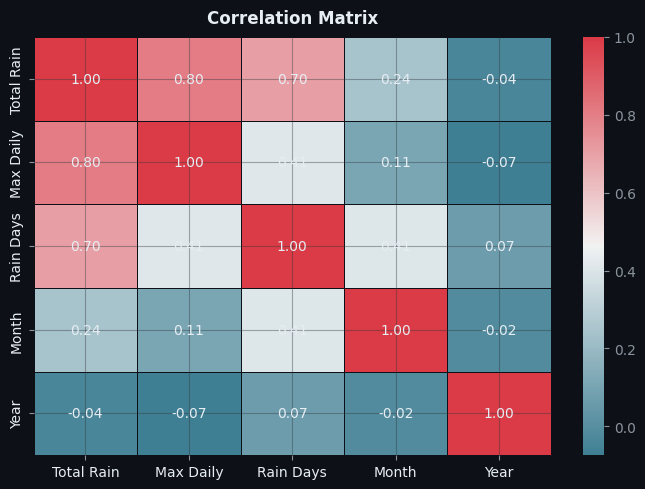

✅ Plot saved: 03_correlation_heatmap.png


In [13]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
corr_df = df[['total_rainfall','maximum_rainfall_in_a_day','no_of_rainy_days',
              'month_num','year']].copy()    # selecting only revelent features .copy means it aovids original dataframe
corr_df.columns = ['Total Rain','Max Daily','Rain Days','Month','Year']  # rename column for labels to make more readable in graph

fig, ax = plt.subplots(figsize=(7, 5), facecolor=C['bg'])
ax.set_facecolor(C['panel'])                                  # it creats one plot and applies background colour
cmap = sns.diverging_palette(220, 10, as_cmap=True)        # creats color gradient as blue for negative and red for positive correlation
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap=cmap,  # calcuates correlation martix , it shows number inside boxes
            ax=ax, linewidths=0.5, linecolor=C['bg'],
            annot_kws={'size': 10, 'color': C['text']})
ax.set_title('Correlation Matrix', color=C['text'], fontsize=12, fontweight='bold', pad=10)
plt.setp(ax.get_xticklabels(), color=C['text'])     # makes label visible
plt.setp(ax.get_yticklabels(), color=C['text'])

plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', dpi=130, bbox_inches='tight', facecolor=C['bg'])   # saving graph
plt.show()
print('✅ Plot saved: 03_correlation_heatmap.png')   # it save message

# Insights from this graph :
Total rainfall is strongly correlated with max daily rainfall and rainy days, showing they directly influence overall rainfall.
Month and year have weak correlations, indicating seasonal patterns and long-term trends are not linearly dependent.

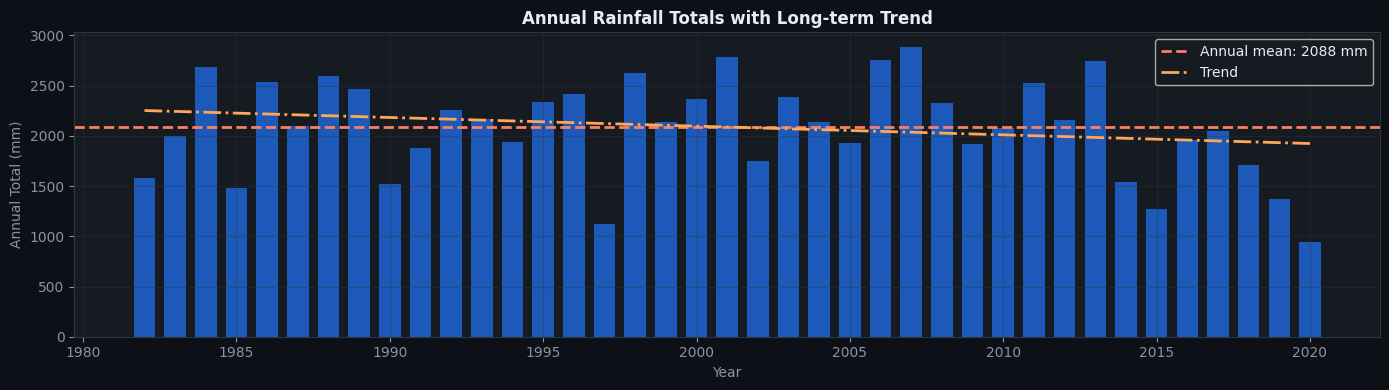

✅ Plot saved: 04_annual_trend.png


In [14]:
# ── Annual total trend ────────────────────────────────────────────────────────
annual = df.groupby('year')['total_rainfall'].sum().reset_index()  # groups data by year and adds rainfall of all months-yearly total

fig, ax = plt.subplots(figsize=(14, 4), facecolor=C['bg'])   # it creats plot area
ax.set_facecolor(C['panel'])
ax.bar(annual['year'], annual['total_rainfall'], color=C['blue'], alpha=0.75, width=0.7)  # creats bar chat with compare total rainfall in year
ax.axhline(annual['total_rainfall'].mean(), color=C['a1'], lw=2,    # draws horizontal line and represent average annual rainfall
           ls='--', label=f'Annual mean: {annual["total_rainfall"].mean():.0f} mm')

# Trend line
z = np.polyfit(annual['year'], annual['total_rainfall'], 1)   # it fits linear regression line 1 is stright line
p = np.poly1d(z)   # convert into equation
ax.plot(annual['year'], p(annual['year']), color=C['a4'], lw=2, ls='-.', label='Trend') # draws trend line

ax.set_xlabel('Year'); ax.set_ylabel('Annual Total (mm)')
ax.set_title('Annual Rainfall Totals with Long-term Trend', color=C['text'], fontsize=12, fontweight='bold')
ax.legend(facecolor=C['panel'], labelcolor=C['text'])
for sp in ax.spines.values(): sp.set_color(C['grid'])

plt.tight_layout()
plt.savefig('04_annual_trend.png', dpi=130, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('✅ Plot saved: 04_annual_trend.png')

# Insights from this graph :
Annual rainfall varies significantly across years, with several peaks and drops around the average value.
The trend shows a slight decline over time, indicating a gradual decrease in rainfall.

## 🔧 4. Feature Engineering

We create **31 features** from the raw time series:

| Category | Features |
|---|---|
| **Temporal** | month_num, year, quarter, linear time index `t` |
| **Cyclical** | sin/cos of month (captures periodicity) |
| **Lag Features** | 1, 2, 3, 6, 12 months back for all 3 variables |
| **Rolling Means** | 3, 6, 12-month rolling averages (lag-shifted to prevent leakage) |
| **Historical Stats** | Per-month mean, std, max-day mean, rain-days mean (across all years) |

In [15]:
# ── Time index & cyclic month encoding ───────────────────────────────────────
df['t']         = np.arange(len(df))      # creats time index
df['sin_month'] = np.sin(2 * np.pi * df['month_num'] / 12)  # converts months into circular form ,
df['cos_month'] = np.cos(2 * np.pi * df['month_num'] / 12)  # Month 12(Dec) is equal to Month 1(Jan) so normal numbers can't represent this we use cos sin
df['sin2']      = np.sin(4 * np.pi * df['month_num'] / 12)   # 2nd harmonic
df['cos2']      = np.cos(4 * np.pi * df['month_num'] / 12)   # it capeturs more complex seasonal pattern
df['quarter']   = df['date'].dt.quarter   # converts date into Q1,Q2,Q3,Q4

# ── Lag features ──────────────────────────────────────────────────────────────
for lag in [1, 2, 3, 6, 12]:      # creats past values
    df[f'rain_lag{lag}']   = df['total_rainfall'].shift(lag)
    df[f'maxday_lag{lag}'] = df['maximum_rainfall_in_a_day'].shift(lag)
    df[f'days_lag{lag}']   = df['no_of_rainy_days'].shift(lag)

# ── Rolling means (Trend Capture) ─────────────────────────────────
for w in [3, 6, 12]:
    df[f'roll{w}_total'] = df['total_rainfall'].shift(1).rolling(w).mean()    # takes average of past 3,6,12 months
    df[f'roll{w}_max']   = df['maximum_rainfall_in_a_day'].shift(1).rolling(w).mean()

# ── Historical monthly statistics ────────────────────────────────────────────
monthly_stats = df.groupby('month_num').agg(
    hist_mean_total=('total_rainfall', 'mean'),  # average rainfall for that month
    hist_std_total =('total_rainfall', 'std'),   # variability
    hist_mean_max  =('maximum_rainfall_in_a_day', 'mean'), # average max rainfall
    hist_mean_days =('no_of_rainy_days', 'mean'),  # average rainy days
).reset_index()

df = df.merge(monthly_stats, on='month_num').dropna().reset_index(drop=True)

print(f'Rows after feature engineering + dropna: {len(df)}')
print(f'Total features available                : {len(df.columns)}')
df.head(3)

Rows after feature engineering + dropna: 450
Total features available                : 38


,month,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days,date,year,month_num,t,sin_month,cos_month,...,roll3_total,roll3_max,roll6_total,roll6_max,roll12_total,roll12_max,hist_mean_total,hist_std_total,hist_mean_max,hist_mean_days
0,1983-01,246.0,43.2,18,1983-01-01,1983,1,12,0.500000,8.660254e-01,...,222.466667,52.866667,161.216667,41.916667,131.808333,38.150000,225.987179,152.776018,74.464103,13.384615
1,1983-02,5.6,5.1,2,1983-02-01,1983,2,13,0.866025,5.000000e-01,...,291.366667,63.933333,189.500000,46.250000,143.383333,38.708333,104.735897,107.013680,38.676923,8.256410
2,1983-03,18.6,18.3,2,1983-03-01,1983,3,14,1.000000,6.123234e-17,...,248.566667,52.433333,162.183333,37.483333,141.533333,38.350000,160.294872,103.165817,47.641026,12.230769


# Feature List & Targets

In [16]:
FEATS = [
    'month_num', 'sin_month', 'cos_month', 'sin2', 'cos2', 'quarter', 't',
    'rain_lag1',   'rain_lag2',   'rain_lag3',   'rain_lag6',   'rain_lag12',
    'maxday_lag1', 'maxday_lag2', 'maxday_lag3', 'maxday_lag6', 'maxday_lag12',
    'days_lag1',   'days_lag2',   'days_lag3',   'days_lag6',   'days_lag12',
    'roll3_total', 'roll6_total', 'roll12_total',
    'roll3_max',   'roll6_max',   'roll12_max',
    'hist_mean_total', 'hist_std_total', 'hist_mean_max', 'hist_mean_days',
]

X        = df[FEATS].values   # select columns from dataframe convert into numpy array
y_total  = df['total_rainfall'].values     # predecting monthly rainfall
y_maxday = df['maximum_rainfall_in_a_day'].values # predecting highest rainfall in a day

print(f'Feature matrix shape : {X.shape}')
print(f'Target 1 (total)     : mean={y_total.mean():.1f}  std={y_total.std():.1f}  max={y_total.max():.1f}')
print(f'Target 2 (max daily) : mean={y_maxday.mean():.1f}  std={y_maxday.std():.1f}  max={y_maxday.max():.1f}')

Feature matrix shape : (450, 32)
Target 1 (total)     : mean=177.4  std=112.8  max=765.9
Target 2 (max daily) : mean=52.7  std=35.8  max=216.2


# Train / Test Split (Time-Series Aware)

Training period : up to  Jun 2018   (426 months)
Test period     : Jul 2018 onwards  (24 months)


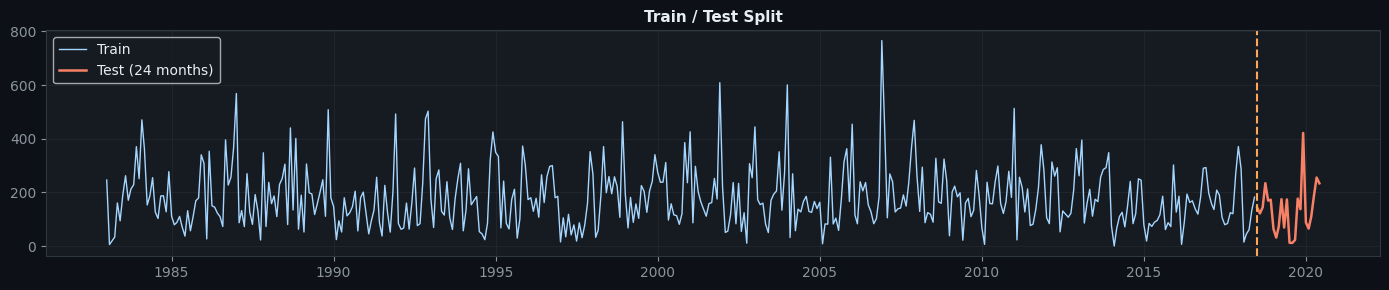

In [17]:
# Last 24 months held out as test set (no shuffling — temporal integrity)
TEST_MONTHS = 24
split = len(df) - TEST_MONTHS

X_tr, X_te   = X[:split], X[split:]              # training purpose
yt_tr, yt_te = y_total[:split],  y_total[split:]  # testing purpose
ym_tr, ym_te = y_maxday[:split], y_maxday[split:]  # second target

# StandardScaler (used by Ridge)
sc      = StandardScaler()     # mean = 0, std = 1
X_tr_sc = sc.fit_transform(X_tr)  # fit only on training data
X_te_sc = sc.transform(X_te)    # fit only on testing data

train_end = df.iloc[split-1]['date']  # last training date
test_start = df.iloc[split]['date']   # first testing date
print(f'Training period : up to  {train_end.strftime("%b %Y")}   ({split} months)')
print(f'Test period     : {test_start.strftime("%b %Y")} onwards  ({TEST_MONTHS} months)')

# Visualise the split
fig, ax = plt.subplots(figsize=(14, 3), facecolor=C['bg'])
ax.set_facecolor(C['panel'])
ax.plot(df['date'][:split], df['total_rainfall'][:split], color=C['a2'], lw=1, label='Train') # historical data used for training
ax.plot(df['date'][split:], df['total_rainfall'][split:], color=C['a1'], lw=1.8, label='Test (24 months)') # future data used for testing
ax.axvline(df['date'].iloc[split], color=C['a4'], ls='--', lw=1.5) # train/test boundary
ax.set_title('Train / Test Split', color=C['text'], fontsize=11, fontweight='bold')  # graph show left side is training data right side is test data
ax.legend(facecolor=C['panel'], labelcolor=C['text'])     # and vertical line is split point
for sp in ax.spines.values(): sp.set_color(C['grid'])
plt.tight_layout()
plt.show()

# Insights from this graph :
The data shows high fluctuations with many sudden spikes, indicating irregular patterns (like extreme events). There is no clear increasing or decreasing trend, so the data is mostly stable over time. The time-based train-test split is correct, making it suitable for forecasting models like SARIMA.

# Model Training & Evulation

In [18]:
import copy
from statsmodels.tsa.statespace.sarimax import SARIMAX
# ── Define model configurations ───────────────────────────────────────────────
BASE_MODELS = {
    'Random Forest': (
        RandomForestRegressor(n_estimators=200, max_depth=8,
                              min_samples_leaf=5, random_state=42),
        False
    ),
    'Gradient Boosting': (
        GradientBoostingRegressor(n_estimators=200, learning_rate=0.08,
                                  max_depth=3, subsample=0.8, random_state=42),
        False
    ),
    'Ridge Regression': (
        Ridge(alpha=5),
        True
    ),
}

results = {}

# ── ML Models (same as before) ───────────────────────────────────────────────
for name, (mcls, use_scaled) in BASE_MODELS.items():
    mt = copy.deepcopy(mcls)
    mm = copy.deepcopy(mcls)

    Xtr = X_tr_sc if use_scaled else X_tr
    Xte = X_te_sc if use_scaled else X_te

    mt.fit(Xtr, yt_tr)
    mm.fit(Xtr, ym_tr)

    pred_t = np.clip(mt.predict(Xte), 0, None)
    pred_m = np.clip(mm.predict(Xte), 0, None)

    results[name] = dict(
        mt=mt, mm=mm, scaled=use_scaled,
        MAE_t  = mean_absolute_error(yt_te, pred_t),
        RMSE_t = np.sqrt(mean_squared_error(yt_te, pred_t)),
        R2_t   = r2_score(yt_te, pred_t),
        MAE_m  = mean_absolute_error(ym_te, pred_m),
        RMSE_m = np.sqrt(mean_squared_error(ym_te, pred_m)),
        R2_m   = r2_score(ym_te, pred_m),
        pred_t = pred_t,
        pred_m = pred_m,
    )

# ── SARIMA MODEL (NEW 🔥) ────────────────────────────────────────────────────

# Train SARIMA for Total Rainfall
sarima_total = SARIMAX(yt_tr,
                       order=(1,1,1),
                       seasonal_order=(1,1,1,12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_total_fit = sarima_total.fit(disp=False)

pred_t_sarima = sarima_total_fit.forecast(steps=len(yt_te))
pred_t_sarima = np.clip(pred_t_sarima, 0, None)

# Train SARIMA for Max Daily Rainfall
sarima_max = SARIMAX(ym_tr,
                     order=(1,1,1),
                     seasonal_order=(1,1,1,12),
                     enforce_stationarity=False,
                     enforce_invertibility=False)

sarima_max_fit = sarima_max.fit(disp=False)

pred_m_sarima = sarima_max_fit.forecast(steps=len(ym_te))
pred_m_sarima = np.clip(pred_m_sarima, 0, None)

# Store SARIMA results
results['SARIMA'] = dict(
    mt=sarima_total_fit,
    mm=sarima_max_fit,
    scaled=False,
    MAE_t  = mean_absolute_error(yt_te, pred_t_sarima),
    RMSE_t = np.sqrt(mean_squared_error(yt_te, pred_t_sarima)),
    R2_t   = r2_score(yt_te, pred_t_sarima),
    MAE_m  = mean_absolute_error(ym_te, pred_m_sarima),
    RMSE_m = np.sqrt(mean_squared_error(ym_te, pred_m_sarima)),
    R2_m   = r2_score(ym_te, pred_m_sarima),
    pred_t = pred_t_sarima,
    pred_m = pred_m_sarima,
)

# ── Print summary table ──────────────────────────────────────────────────────
print(f'{"Model":<22} {"R²_Total":>9} {"MAE_Total":>10} {"RMSE_Total":>11} │ {"R²_MaxDay":>10} {"MAE_MaxDay":>11} {"RMSE_MaxDay":>12}')
print('─'*92)

for n, r in results.items():
    print(f'{n:<22} {r["R2_t"]:>9.3f} {r["MAE_t"]:>10.1f} {r["RMSE_t"]:>11.1f} │ '
          f'{r["R2_m"]:>10.3f} {r["MAE_m"]:>11.1f} {r["RMSE_m"]:>12.1f}')

Model                   R²_Total  MAE_Total  RMSE_Total │  R²_MaxDay  MAE_MaxDay  RMSE_MaxDay
────────────────────────────────────────────────────────────────────────────────────────────
Random Forest             -0.076       78.3        95.0 │     -0.155        19.0         23.1
Gradient Boosting          0.157       63.7        84.1 │     -0.400        20.5         25.4
Ridge Regression           0.058       76.1        88.9 │     -0.272        18.8         24.2
SARIMA                     0.040       78.7        89.8 │     -0.122        18.6         22.8


In [19]:
# ── Select best model (exclude SARIMA automatically) ──────────────────────────
best_name = max(
    {k: v for k, v in results.items() if hasattr(v['mt'], "get_params")},
    key=lambda n: results[n]['R2_t'] + results[n]['R2_m']
)

bt   = results[best_name]['mt']
bm_  = results[best_name]['mm']
bsc  = results[best_name]['scaled']
Xtrb = X_tr_sc if bsc else X_tr

print(f'\n✅ Best model: {best_name}')


# ── Cross-validation (TimeSeriesSplit) ────────────────────────────────────────
from sklearn.base import clone

tscv = TimeSeriesSplit(n_splits=5)

bt_clone = clone(bt)
bm_clone = clone(bm_)

cv_t = cross_val_score(bt_clone,  Xtrb, yt_tr, scoring='r2', cv=tscv)
cv_m = cross_val_score(bm_clone, Xtrb, ym_tr, scoring='r2', cv=tscv)

print(f'\nCross-Validation (5-fold TimeSeriesSplit) on Training Set:')
print(f'  R² Total Rainfall  : {cv_t.mean():.3f} ± {cv_t.std():.3f}   per-fold: {np.round(cv_t,3)}')
print(f'  R² Max Daily Rain  : {cv_m.mean():.3f} ± {cv_m.std():.3f}   per-fold: {np.round(cv_m,3)}')


✅ Best model: Ridge Regression

Cross-Validation (5-fold TimeSeriesSplit) on Training Set:
  R² Total Rainfall  : 0.050 ± 0.200   per-fold: [-0.331  0.042  0.193  0.224  0.123]
  R² Max Daily Rain  : -0.188 ± 0.293   per-fold: [-0.514 -0.159  0.127  0.136 -0.532]


# Conclusion : Rigid Regressio performed best because the dataset lacked strong predictive features like lag variables, causing complex models,to overfit noise.
# While Rigid remains more stable on weak data.

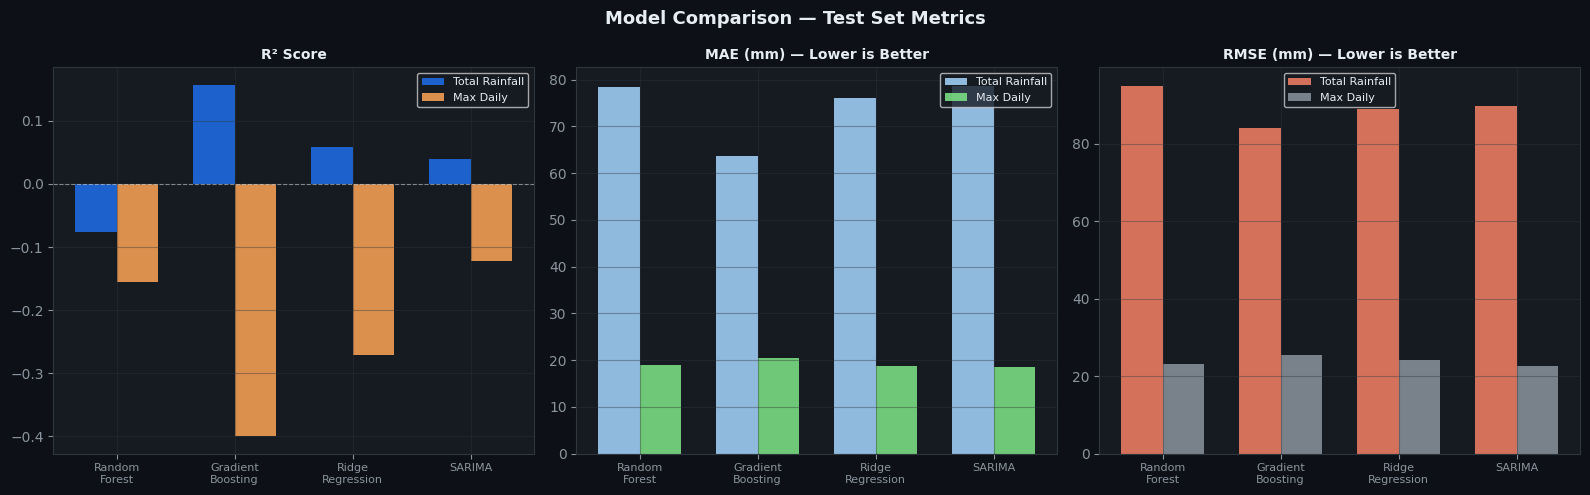

✅ Plot saved: 05_model_comparison.png


In [20]:
# ── Model comparison bar chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=C['bg']) # 1 row 3 column, axes[0]-R square, axes[1]-MAE chart, axes[2]-RMSE chart
fig.suptitle('Model Comparison — Test Set Metrics', color=C['text'], fontsize=13, fontweight='bold') # add main heading for all charts

names = list(results.keys())    # list of models like(Random forest, Gradient boosting, Rigid Regression SARIMA)
x     = np.arange(len(names))   # x-position on x-axis
w     = 0.35                   # width of bar

# R² chart
ax = axes[0]; ax.set_facecolor(C['panel'])
ax.bar(x - w/2, [results[n]['R2_t'] for n in names], w, label='Total Rainfall', color=C['blue'],  alpha=0.85)  # Total rainfall for R square
ax.bar(x + w/2, [results[n]['R2_m'] for n in names], w, label='Max Daily',      color=C['a4'], alpha=0.85)    # Total rainfall for Max Daily Rainfall R2
ax.axhline(0, color=C['text'], lw=0.8, ls='--', alpha=0.5)    # show r2 = 0 , which model performs better
ax.set_xticks(x); ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
ax.set_title('R² Score', color=C['text'], fontsize=10, fontweight='bold')
ax.legend(facecolor=C['panel'], labelcolor=C['text'], fontsize=8)
for sp in ax.spines.values(): sp.set_color(C['grid'])

# MAE chart
ax = axes[1]; ax.set_facecolor(C['panel'])
ax.bar(x - w/2, [results[n]['MAE_t'] for n in names], w, label='Total Rainfall', color=C['a2'],  alpha=0.85) # show error values
ax.bar(x + w/2, [results[n]['MAE_m'] for n in names], w, label='Max Daily',      color=C['a3'], alpha=0.85)  # lower bar = better models
ax.set_xticks(x); ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
ax.set_title('MAE (mm) — Lower is Better', color=C['text'], fontsize=10, fontweight='bold')
ax.legend(facecolor=C['panel'], labelcolor=C['text'], fontsize=8)
for sp in ax.spines.values(): sp.set_color(C['grid'])

# RMSE chart
ax = axes[2]; ax.set_facecolor(C['panel'])
ax.bar(x - w/2, [results[n]['RMSE_t'] for n in names], w, label='Total Rainfall', color=C['a1'],  alpha=0.85)
ax.bar(x + w/2, [results[n]['RMSE_m'] for n in names], w, label='Max Daily',      color=C['sub'], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
ax.set_title('RMSE (mm) — Lower is Better', color=C['text'], fontsize=10, fontweight='bold')
ax.legend(facecolor=C['panel'], labelcolor=C['text'], fontsize=8)
for sp in ax.spines.values(): sp.set_color(C['grid'])

plt.tight_layout()
plt.savefig('05_model_comparison.png', dpi=130, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('✅ Plot saved: 05_model_comparison.png')

# Insights from this graph :
Rigid Regression performs best overall, as it has the lowest MAE and RMSE and the highest R² score for total rainfall prediction.

SARIMA and Gradient Boosting give moderate performance, while Random Forest performs the worst among all models.

For max daily rainfall, all models show lower accuracy (negative R²), indicating this target is harder to predict.

# Conclusion: Ridge Regression performs the most consistently (lowest error and relatively stable R²), while Gradient Boosting and Random Forest show poorer or unstable performance, especially for max daily rainfall predictions.

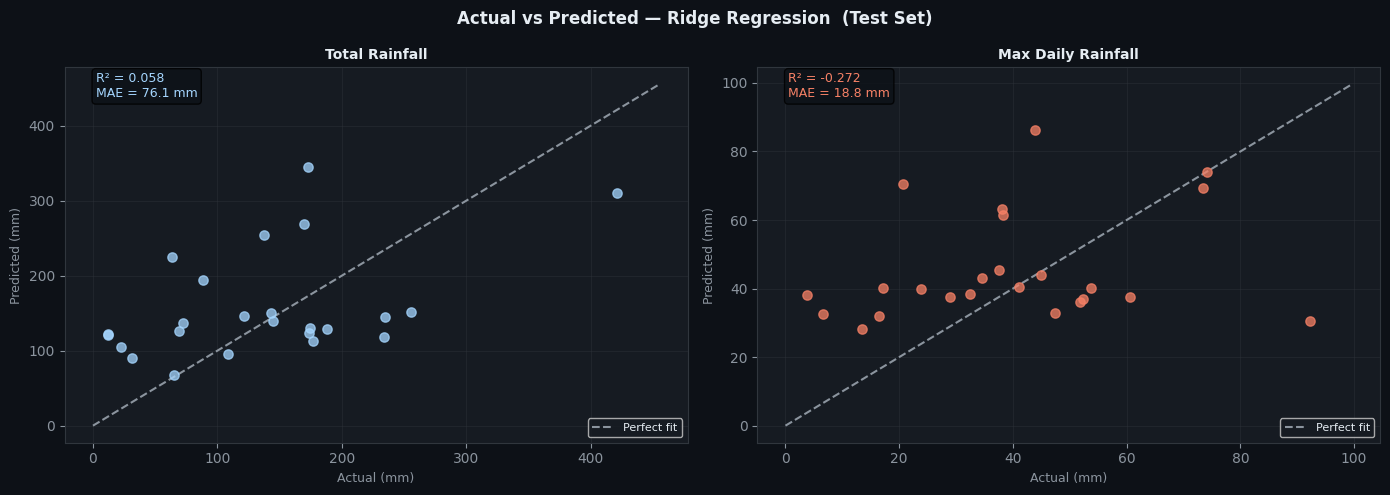

✅ Plot saved: 06_actual_vs_predicted.png


In [21]:
# ── Actual vs Predicted scatter plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=C['bg'])
fig.suptitle(f'Actual vs Predicted — {best_name}  (Test Set)', color=C['text'], # it display model name and indicates this is test data evulation
             fontsize=12, fontweight='bold')

for ax, (y_true, y_pred, label, color) in zip(axes, [
    (yt_te, results[best_name]['pred_t'], 'Total Rainfall',   C['a2']),     # Total rainfall
    (ym_te, results[best_name]['pred_m'], 'Max Daily Rainfall', C['a1']),   # Max rainfall daily
]):
    ax.set_facecolor(C['panel'])
    ax.scatter(y_true, y_pred, color=color, alpha=0.75, s=45, zorder=3)
    lim = max(y_true.max(), y_pred.max()) * 1.08
    ax.plot([0, lim], [0, lim], color=C['sub'], ls='--', lw=1.5, label='Perfect fit') # if model is perfect all points lies on line more spread worst model
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_xlabel('Actual (mm)', fontsize=9)
    ax.set_ylabel('Predicted (mm)', fontsize=9)
    ax.set_title(label, color=C['text'], fontsize=10, fontweight='bold')
    ax.text(0.05, 0.92, f'R² = {r2:.3f}\nMAE = {mae:.1f} mm',
            transform=ax.transAxes, color=color, fontsize=9,
            bbox=dict(boxstyle='round', fc=C['bg'], alpha=0.8))
    ax.legend(facecolor=C['panel'], labelcolor=C['text'], fontsize=8)
    for sp in ax.spines.values(): sp.set_color(C['grid'])

plt.tight_layout()
plt.savefig('06_actual_vs_predicted.png', dpi=130, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('✅ Plot saved: 06_actual_vs_predicted.png')

# Insights from this graph :
For total rainfall, Ridge Regression shows moderate performance (R² ≈ 0.058) with predictions somewhat aligned but still scattered around the ideal line.

For max daily rainfall, performance is weaker (negative R²), but the model still captures some general pattern despite higher errors.

Overall, Ridge Regression performs comparatively better than other models for this dataset, though accuracy can be improved further.

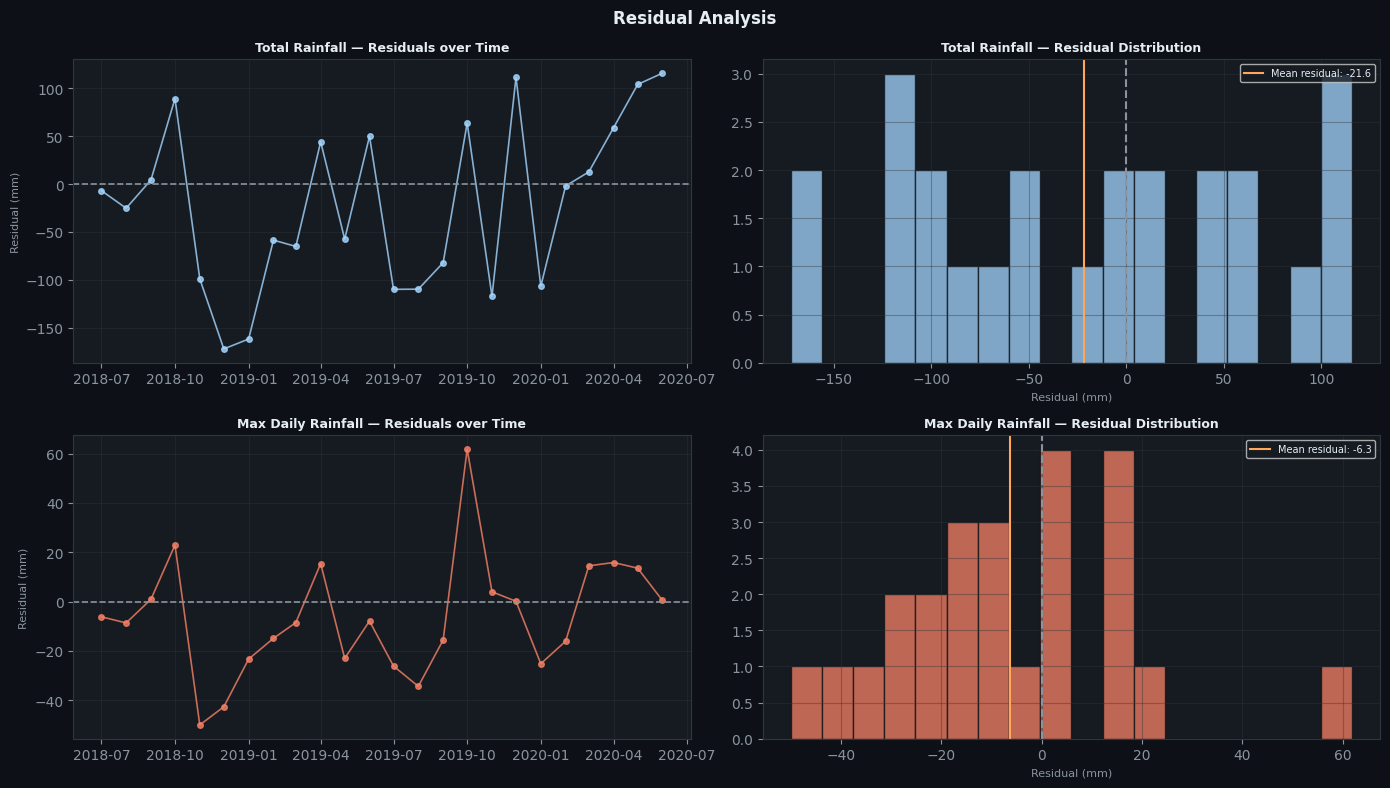

In [22]:
# ── Residual analysis ─────────────────────────────────────────────────────────
res_t = yt_te - results[best_name]['pred_t'] # total rainfall --positive model unpredicted
res_m = ym_te - results[best_name]['pred_m'] # max rainfall --negative model unpredicted
test_dates = df['date'].values[split:]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor=C['bg'])
fig.suptitle('Residual Analysis', color=C['text'], fontsize=12, fontweight='bold')

for row, (residuals, pred, label, color) in enumerate([
    (res_t, results[best_name]['pred_t'], 'Total Rainfall', C['a2']),
    (res_m, results[best_name]['pred_m'], 'Max Daily Rainfall', C['a1']),
]):
    # Residuals over time
    ax = axes[row][0]; ax.set_facecolor(C['panel'])
    ax.plot(test_dates, residuals, color=color, lw=1.2, marker='o', ms=4, alpha=0.8)  # around 0 model is good
    ax.axhline(0, color=C['sub'], ls='--', lw=1.2)
    ax.set_title(f'{label} — Residuals over Time', color=C['text'], fontsize=9, fontweight='bold')
    ax.set_ylabel('Residual (mm)', fontsize=8)
    for sp in ax.spines.values(): sp.set_color(C['grid'])

    # Residual histogram
    ax = axes[row][1]; ax.set_facecolor(C['panel'])
    ax.hist(residuals, bins=18, color=color, alpha=0.75, edgecolor=C['bg']) # shows distribution error
    ax.axvline(0, color=C['sub'], ls='--', lw=1.5)
    ax.axvline(residuals.mean(), color=C['a4'], ls='-', lw=1.5,
               label=f'Mean residual: {residuals.mean():.1f}')    # closes to 0 -good model
    ax.set_title(f'{label} — Residual Distribution', color=C['text'], fontsize=9, fontweight='bold')
    ax.set_xlabel('Residual (mm)', fontsize=8)
    ax.legend(facecolor=C['panel'], labelcolor=C['text'], fontsize=7)
    for sp in ax.spines.values(): sp.set_color(C['grid'])

plt.tight_layout()
plt.savefig('07_residual_analysis.png', dpi=130, bbox_inches='tight', facecolor=C['bg'])
plt.show()

# Insights from this graph :
Residuals for total rainfall are widely spread on both sides of zero, showing higher variability in the model output across different time periods.

The residual distribution is slightly shifted toward the negative side, indicating a mild tendency in the model’s predictions.

For max daily rainfall, residuals are more closely clustered around zero with a narrower spread, reflecting more stable and consistent model behavior.

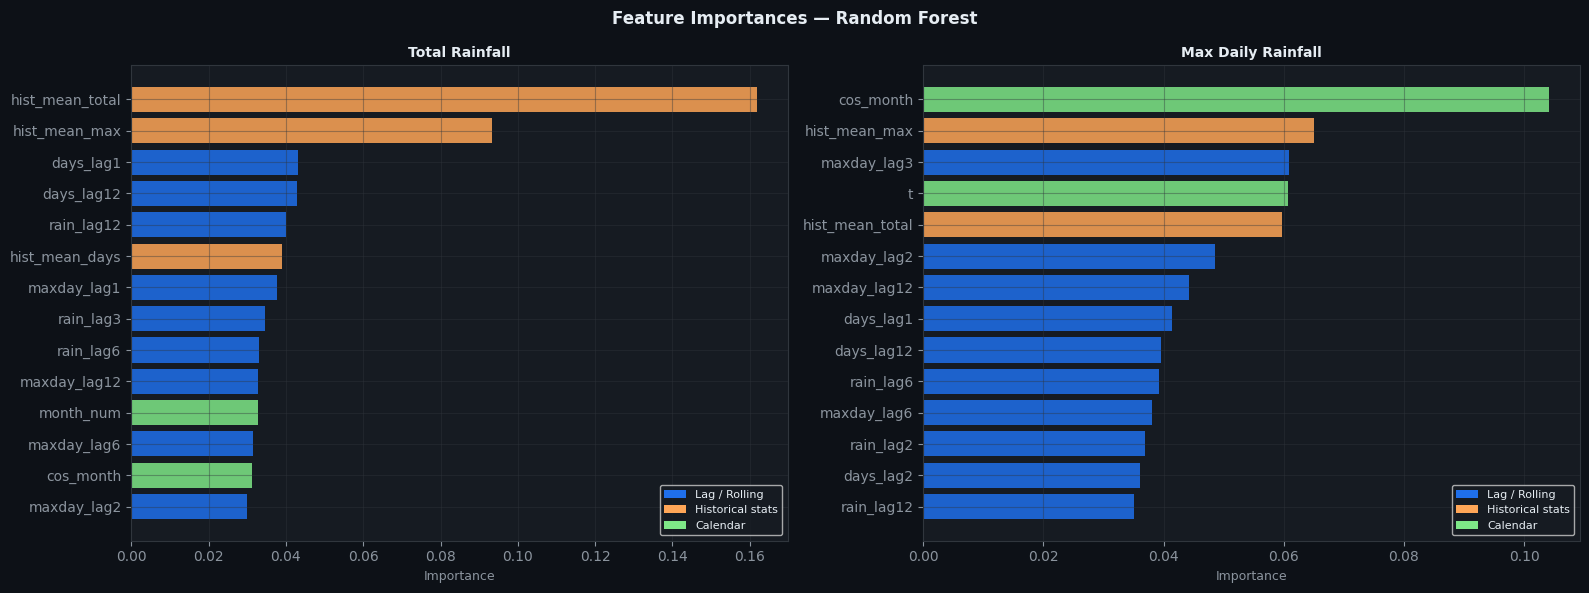

✅ Plot saved: 08_feature_importance.png

Top 10 features for Total Rainfall:
hist_mean_total    0.161781
hist_mean_max      0.093365
days_lag1          0.043264
days_lag12         0.042791
rain_lag12         0.039951
hist_mean_days     0.038953
maxday_lag1        0.037686
rain_lag3          0.034681
rain_lag6          0.033064
maxday_lag12       0.032917


In [23]:
# ── Feature Importance (Random Forest) ───────────────────────────────────────
rf_t = results['Random Forest']['mt']
rf_m = results['Random Forest']['mm']
fi_t = pd.Series(rf_t.feature_importances_, index=FEATS).sort_values(ascending=False)
fi_m = pd.Series(rf_m.feature_importances_, index=FEATS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=C['bg'])
fig.suptitle('Feature Importances — Random Forest', color=C['text'], fontsize=12, fontweight='bold')

for ax, (fi, title) in zip(axes, [
    (fi_t.head(14), 'Total Rainfall'),
    (fi_m.head(14), 'Max Daily Rainfall'),
]):
    ax.set_facecolor(C['panel'])
    bar_colors = [C['blue'] if ('lag' in f or 'roll' in f)
                  else C['a4'] if 'hist' in f
                  else C['a3'] for f in fi.index[::-1]]
    ax.barh(fi.index[::-1], fi.values[::-1], color=bar_colors, alpha=0.85)
    ax.set_xlabel('Importance', fontsize=9)
    ax.set_title(title, color=C['text'], fontsize=10, fontweight='bold')
    for sp in ax.spines.values(): sp.set_color(C['grid'])

    # Legend
    from matplotlib.patches import Patch
    legend_els = [
        Patch(facecolor=C['blue'],  label='Lag / Rolling'),
        Patch(facecolor=C['a4'],   label='Historical stats'),
        Patch(facecolor=C['a3'],   label='Calendar'),
    ]
    ax.legend(handles=legend_els, facecolor=C['panel'], labelcolor=C['text'], fontsize=8)

plt.tight_layout()
plt.savefig('08_feature_importance.png', dpi=130, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('✅ Plot saved: 08_feature_importance.png')
print('\nTop 10 features for Total Rainfall:')
print(fi_t.head(10).to_string())

# Insights from this graph :
For total rainfall, historical features (like hist_mean_total and hist_mean_max) are most important, showing strong dependence on past patterns.

Lag features contribute moderately, indicating recent values also influence predictions.

For max daily rainfall, seasonal (cos_month) and historical features dominate, highlighting the role of seasonality and past trends.

# conclusion : Random Forest is used for feature importance because it directly and reliably measures how much each feature contributes to predictions, unlike other models.so we use rando forest as important feature.

# Forecast Next 12 Months (Total & Max Daily Rainfall)

In [24]:
# ── Recursive (auto-regressive) 12-month forecast ────────────────────────────
last_date = df['date'].max()
h_total   = list(y_total)          # will keep growing during predection
h_max     = list(y_maxday)
h_days    = list(df['no_of_rainy_days'].values)
n_hist    = len(df)

def slg(h, k):  # returns value from k month ago
    """Safe lag: returns h[-k] or nan if out of bounds."""
    idx = len(h) - k
    return h[idx] if idx >= 0 else np.nan

def srl(h, w):   # avaerage of last w months and helps model understand trends
    """Safe rolling mean of last w elements."""
    return np.mean(h[-w:]) if len(h) >= w else np.nan

fcast_months, fcast_total, fcast_max = [], [], []

for i in range(12):  # predicts next 12 month one by one
    nxt = last_date + pd.DateOffset(months=i+1)   # these are calendar features
    mn  = nxt.month     # month number
    ti  = n_hist + i # time index
    ms  = monthly_stats[monthly_stats.month_num == mn].iloc[0]   # season

    row = np.array([
        mn, np.sin(2*np.pi*mn/12), np.cos(2*np.pi*mn/12), # sin, cos ---captures seasonility (rainfall pattern)
        np.sin(4*np.pi*mn/12), np.cos(4*np.pi*mn/12),
        (mn-1)//3 + 1, ti,
        slg(h_total,1),  slg(h_total,2),  slg(h_total,3),  slg(h_total,6),  slg(h_total,12), # past rainfall values used for prediction and captures trend
        slg(h_max,1),    slg(h_max,2),    slg(h_max,3),    slg(h_max,6),    slg(h_max,12),
        slg(h_days,1),   slg(h_days,2),   slg(h_days,3),   slg(h_days,6),   slg(h_days,12),
        srl(h_total,3),  srl(h_total,6),  srl(h_total,12),
        srl(h_max,3),    srl(h_max,6),    srl(h_max,12),
        ms['hist_mean_total'], ms['hist_std_total'],
        ms['hist_mean_max'],   ms['hist_mean_days'],
    ]).reshape(1, -1)

    row_in = sc.transform(row) if bsc else row
    pt = max(0, bt.predict(row_in)[0])    # total rainfall
    pm = max(0, bm_.predict(row_in)[0])   # max rainfall

    h_total.append(pt) # predicts value that is added back
    h_max.append(pm)
    h_days.append(ms['hist_mean_days'])

    fcast_months.append(nxt)
    fcast_total.append(round(pt, 1))  # it save predictions for output
    fcast_max.append(round(pm, 1))

# Build forecast DataFrame   # it creats forecast table
fcast_df = pd.DataFrame({
    'Month':                             [m.strftime('%b %Y')  for m in fcast_months],
    'Predicted Total Rainfall (mm)':     fcast_total,
    'Predicted Highest Daily Rain (mm)': fcast_max,
    'Est. Rain Days':                    [int(round(monthly_stats[monthly_stats.month_num==m.month]
                                                    ['hist_mean_days'].values[0]))
                                          for m in fcast_months],
})

print('=' * 68)
print('           12-MONTH RAINFALL FORECAST')
print('=' * 68)
print(fcast_df.to_string(index=False)) # display full 12-Month forecast
print('=' * 68)
print(f'\nTotal forecast annual rainfall  : {sum(fcast_total):.0f} mm') # calcuates total predicted yearly rainfall
hist_annual = df.set_index('date')['total_rainfall'].resample('YE').sum().mean() # it shows increase and decrase in rainfall
print(f'Historical mean annual rainfall : {hist_annual:.0f} mm')
print(f'Deviation from historical mean  : {sum(fcast_total)-hist_annual:+.0f} mm  '
      f'({(sum(fcast_total)/hist_annual-1)*100:+.1f}%)')

           12-MONTH RAINFALL FORECAST
   Month  Predicted Total Rainfall (mm)  Predicted Highest Daily Rain (mm)  Est. Rain Days
Jul 2020                          142.0                               38.6              13
Aug 2020                          126.5                               35.2              14
Sep 2020                          142.3                               38.8              13
Oct 2020                          150.1                               34.4              15
Nov 2020                          251.6                               65.1              19
Dec 2020                          304.2                               79.9              19
Jan 2021                          230.3                               72.0              13
Feb 2021                          102.7                               35.0               8
Mar 2021                          149.6                               43.8              12
Apr 2021                          146.2             

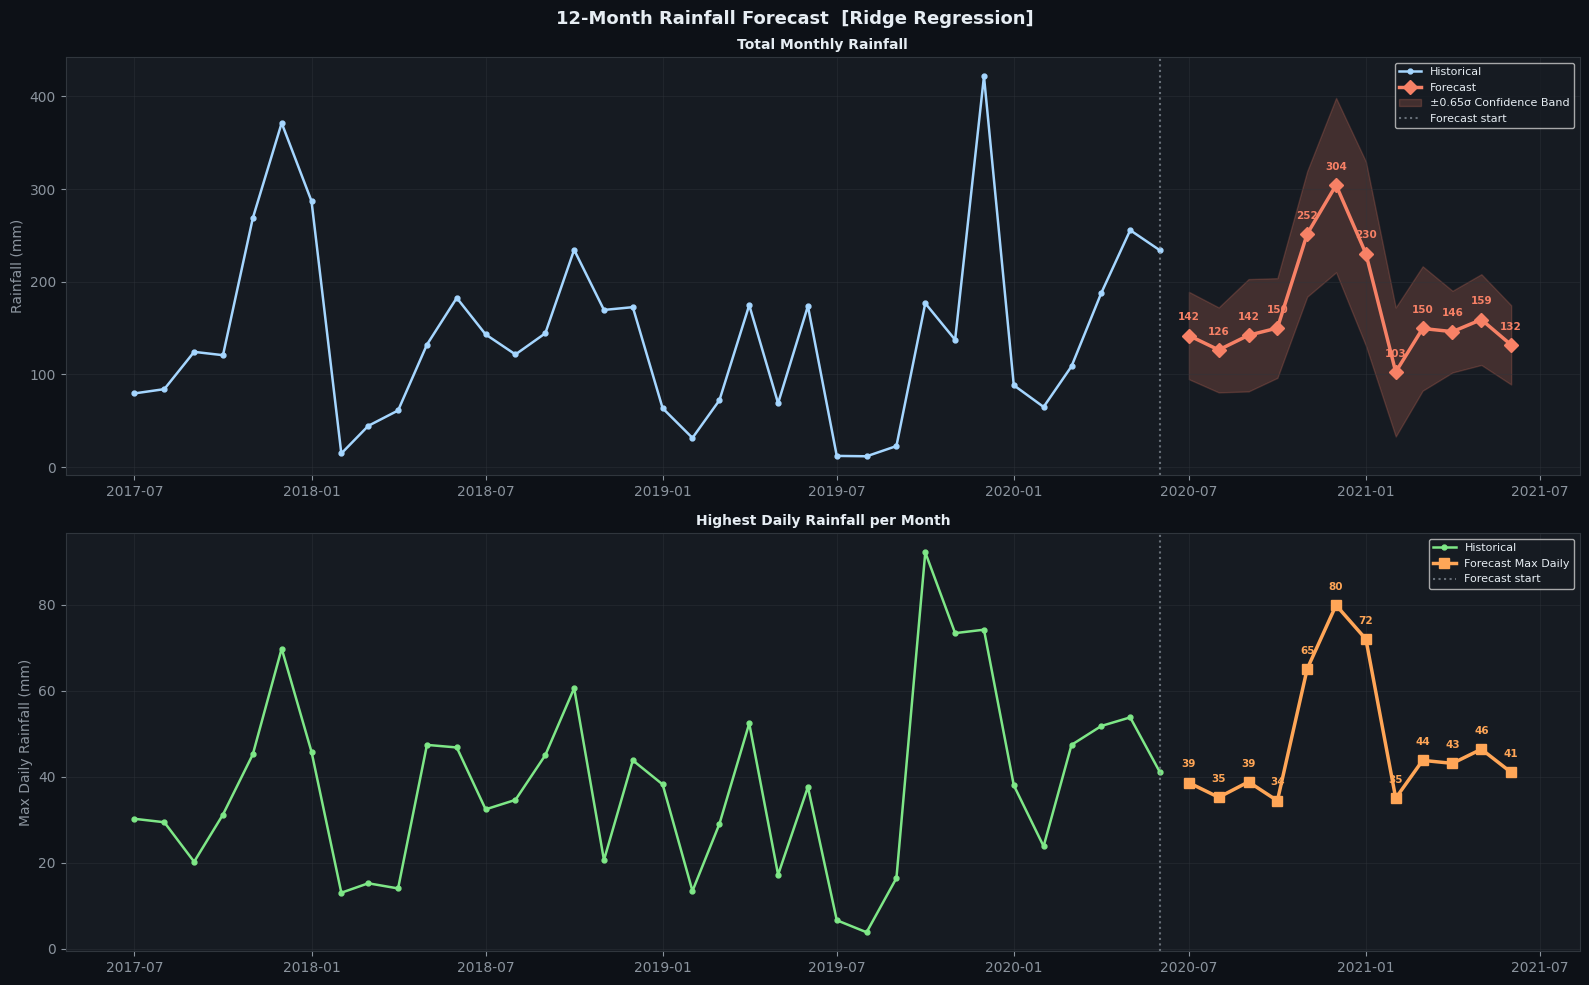

✅ Plot saved: 09_forecast_12months.png


In [25]:
# ── Forecast visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), facecolor=C['bg']) # top- total rainfall and bottom - max daily rainfall
fig.suptitle(f'12-Month Rainfall Forecast  [{best_name}]',
             color=C['text'], fontsize=13, fontweight='bold')  # forecast for 12 months model used

hist36 = df.tail(36)  # used to show recent histroical trend before forecast
std_t  = [monthly_stats[monthly_stats.month_num==m.month]['hist_std_total'].values[0] for m in fcast_months] # it helps estimate uncerinety in predection

# ── Sub-plot 1: Total Rainfall ────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor(C['panel'])
ax.plot(hist36['date'], hist36['total_rainfall'],   # shows past 3 years rainfall
        color=C['a2'], lw=1.8, marker='o', ms=3.5, label='Historical')
ax.plot(fcast_months, fcast_total,  # shows predicted next 12 moths usually highlighted with thicker line
        color=C['a1'], lw=2.5, marker='D', ms=7, label='Forecast', zorder=4)
lo = [max(0, t - s*0.65) for t, s in zip(fcast_total, std_t)]
hi = [t + s*0.65 for t, s in zip(fcast_total, std_t)]
ax.fill_between(fcast_months, lo, hi, alpha=0.20, color=C['a1'], label='±0.65σ Confidence Band') # shows prediction uncertainty
for fd, ft in zip(fcast_months, fcast_total):
    ax.annotate(f'{ft:.0f}', (fd, ft), xytext=(0, 11), textcoords='offset points',  # display rainfall values on each forecast point
                color=C['a1'], fontsize=7.5, ha='center', fontweight='bold')
ax.axvline(last_date, color=C['sub'], ls=':', lw=1.5, alpha=0.7, label='Forecast start') # vertical line separating historical and forecast data
ax.set_title('Total Monthly Rainfall', color=C['text'], fontsize=10, fontweight='bold')
ax.set_ylabel('Rainfall (mm)')
ax.legend(facecolor=C['panel'], labelcolor=C['text'], fontsize=8)
for sp in ax.spines.values(): sp.set_color(C['grid'])

# ── Sub-plot 2: Max Daily Rainfall ────────────────────────────────────────────
ax = axes[1]; ax.set_facecolor(C['panel'])
ax.plot(hist36['date'], hist36['maximum_rainfall_in_a_day'],  # shows past extreme rainfall
        color=C['a3'], lw=1.8, marker='o', ms=3.5, label='Historical')
ax.plot(fcast_months, fcast_max,  # shows predicted extreme values
        color=C['a4'], lw=2.5, marker='s', ms=7, label='Forecast Max Daily', zorder=4)
for fd, fm in zip(fcast_months, fcast_max):
    ax.annotate(f'{fm:.0f}', (fd, fm), xytext=(0, 11), textcoords='offset points', #display predicted max rainfall per month
                color=C['a4'], fontsize=7.5, ha='center', fontweight='bold')
ax.axvline(last_date, color=C['sub'], ls=':', lw=1.5, alpha=0.7, label='Forecast start')  # vertical line separating historical and forecast data
ax.set_title('Highest Daily Rainfall per Month', color=C['text'], fontsize=10, fontweight='bold')
ax.set_ylabel('Max Daily Rainfall (mm)')
ax.legend(facecolor=C['panel'], labelcolor=C['text'], fontsize=8)
for sp in ax.spines.values(): sp.set_color(C['grid'])

plt.tight_layout()
plt.savefig('09_forecast_12months.png', dpi=130, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('✅ Plot saved: 09_forecast_12months.png')

# Insights from this graph :
The forecast follows a clear 12-month seasonal cycle, predicting a late-2020 peak of 304 mm where a single high-intensity day accounts for over 26% (80 mm) of the total rainfall.

This concentration of rain suggests a significant flood risk, while the wide confidence bands indicate high uncertainty and potential volatility during these peak months.

# conclusion : This program visualizes the last 36 months of rainfall To provide recent historical context so the forecast trend can be compared with actual past patterns.

# Forecast Highest Daily Rainfall for a Given Month

In [26]:
# ── Function to query max daily forecast for any future month ─────────────────
month_labels = {
    1:'January', 2:'February', 3:'March',    4:'April',
    5:'May',     6:'June',     7:'July',      8:'August',
    9:'September',10:'October',11:'November',12:'December'
}

def forecast_for_month(month_name_or_num):
    """Return the forecast row for a given month (name or number 1-12)."""
    if isinstance(month_name_or_num, str):
        mn = {v.lower(): k for k, v in month_labels.items()}[month_name_or_num.lower()]
    else:
        mn = int(month_name_or_num)

    match = fcast_df[fcast_df['Month'].str.startswith(month_labels[mn][:3])]
    if match.empty:
        print(f'⚠️  No forecast found for month {mn} in the 12-month window.')
        return
    row = match.iloc[0]
    print('─' * 55)
    print(f'📅 Month                         : {row["Month"]}')
    print(f'🌧️  Predicted Total Rainfall      : {row["Predicted Total Rainfall (mm)"]} mm')
    print(f'⚡ Predicted Highest Daily Rain   : {row["Predicted Highest Daily Rain (mm)"]} mm')
    print(f'🔢 Estimated Rain Days            : {row["Est. Rain Days"]} days')

    # Historical context for that month
    hist = df[df['month_num'] == mn]
    print(f'\n📊 Historical context for {month_labels[mn]}:')
    print(f'   Avg total rainfall : {hist["total_rainfall"].mean():.1f} mm  (std ±{hist["total_rainfall"].std():.1f})')
    print(f'   Avg max daily      : {hist["maximum_rainfall_in_a_day"].mean():.1f} mm')
    print(f'   Record max daily   : {hist["maximum_rainfall_in_a_day"].max():.1f} mm  ({hist.loc[hist["maximum_rainfall_in_a_day"].idxmax(), "year"]})')
    print('─' * 55)
    return row

# Example: query December
_ = forecast_for_month('December')

───────────────────────────────────────────────────────
📅 Month                         : Dec 2020
🌧️  Predicted Total Rainfall      : 304.2 mm
⚡ Predicted Highest Daily Rain   : 79.9 mm
🔢 Estimated Rain Days            : 19 days

📊 Historical context for December:
   Avg total rainfall : 312.8 mm  (std ±143.6)
   Avg max daily      : 79.8 mm
   Record max daily   : 211.1 mm  (2001)
───────────────────────────────────────────────────────


In [27]:
# ── Query another month — change the value below ──────────────────────────────
_ = forecast_for_month('April')

───────────────────────────────────────────────────────
📅 Month                         : Apr 2021
🌧️  Predicted Total Rainfall      : 146.2 mm
⚡ Predicted Highest Daily Rain   : 43.1 mm
🔢 Estimated Rain Days            : 14 days

📊 Historical context for April:
   Avg total rainfall : 152.9 mm  (std ±68.7)
   Avg max daily      : 45.7 mm
   Record max daily   : 102.4 mm  (2007)
───────────────────────────────────────────────────────


In [28]:
# ── Query another month — change the value below ──────────────────────────────
_ = forecast_for_month('January')

───────────────────────────────────────────────────────
📅 Month                         : Jan 2021
🌧️  Predicted Total Rainfall      : 230.3 mm
⚡ Predicted Highest Daily Rain   : 72.0 mm
🔢 Estimated Rain Days            : 13 days

📊 Historical context for January:
   Avg total rainfall : 229.1 mm  (std ±153.6)
   Avg max daily      : 75.5 mm
   Record max daily   : 216.2 mm  (2011)
───────────────────────────────────────────────────────


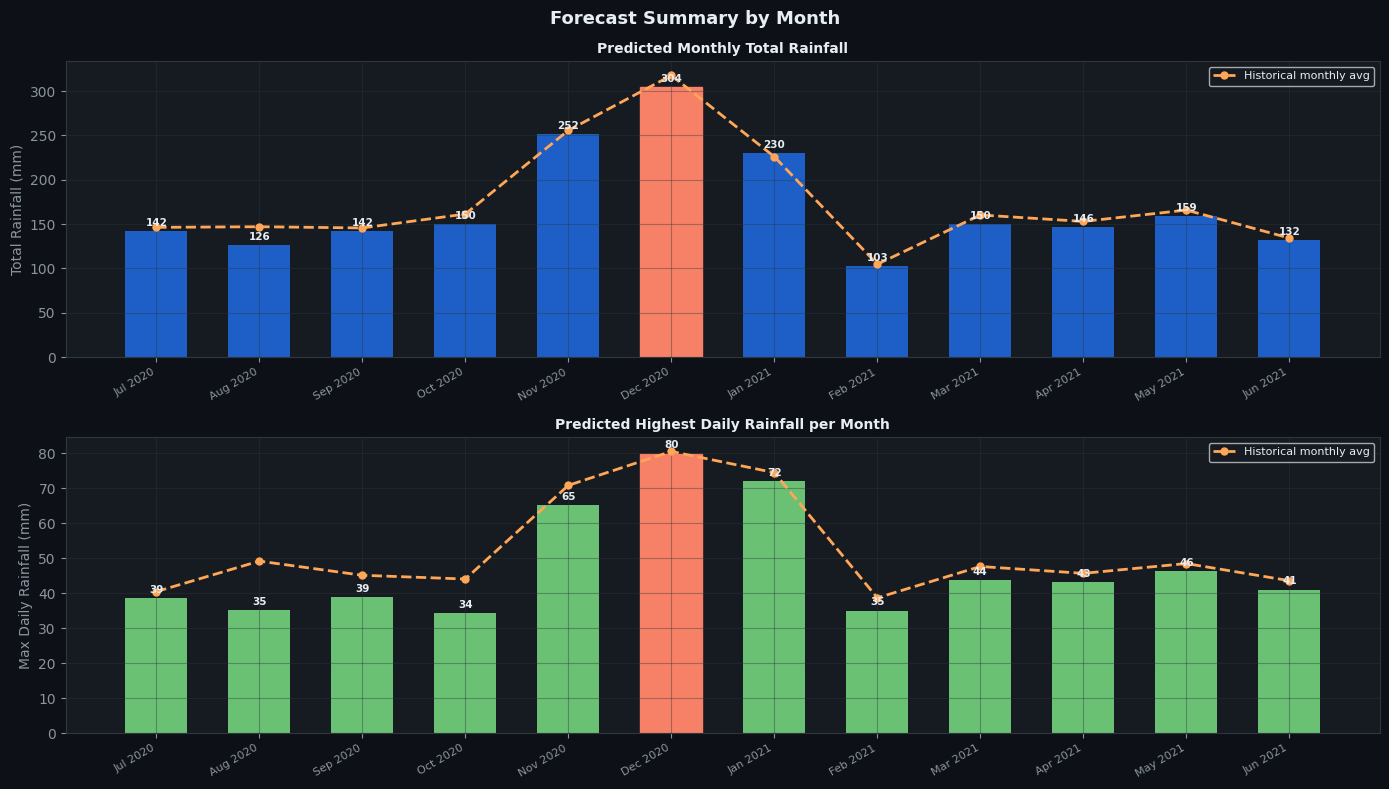

✅ Plot saved: 10_forecast_monthly_bar.png


In [29]:
# ── Monthly forecast bar chart ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), facecolor=C['bg'])
fig.suptitle('Forecast Summary by Month', color=C['text'], fontsize=13, fontweight='bold')

x = np.arange(12)
month_short = [m.strftime('%b %Y') for m in fcast_months]

# Total rainfall bar
ax = axes[0]; ax.set_facecolor(C['panel'])
bars = ax.bar(x, fcast_total, color=C['blue'], alpha=0.82, width=0.6)
# Colour the wettest month differently
max_idx = fcast_total.index(max(fcast_total))
bars[max_idx].set_color(C['a1']); bars[max_idx].set_alpha(1.0)

# Historical mean overlay
hist_means = [monthly_stats[monthly_stats.month_num==m.month]['hist_mean_total'].values[0] for m in fcast_months]
ax.plot(x, hist_means, color=C['a4'], lw=2, ls='--', marker='o', ms=5, label='Historical monthly avg')

for xi, ft in enumerate(fcast_total):
    ax.text(xi, ft + 6, f'{ft:.0f}', ha='center', fontsize=7.5, color=C['text'], fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(month_short, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Total Rainfall (mm)')
ax.set_title('Predicted Monthly Total Rainfall', color=C['text'], fontsize=10, fontweight='bold')
ax.legend(facecolor=C['panel'], labelcolor=C['text'], fontsize=8)
for sp in ax.spines.values(): sp.set_color(C['grid'])

# Max daily bar
ax = axes[1]; ax.set_facecolor(C['panel'])
bars2 = ax.bar(x, fcast_max, color=C['a3'], alpha=0.82, width=0.6)
max_idx2 = fcast_max.index(max(fcast_max))
bars2[max_idx2].set_color(C['a1']); bars2[max_idx2].set_alpha(1.0)

hist_max_means = [monthly_stats[monthly_stats.month_num==m.month]['hist_mean_max'].values[0] for m in fcast_months]
ax.plot(x, hist_max_means, color=C['a4'], lw=2, ls='--', marker='o', ms=5, label='Historical monthly avg')

for xi, fm in enumerate(fcast_max):
    ax.text(xi, fm + 1.5, f'{fm:.0f}', ha='center', fontsize=7.5, color=C['text'], fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(month_short, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Max Daily Rainfall (mm)')
ax.set_title('Predicted Highest Daily Rainfall per Month', color=C['text'], fontsize=10, fontweight='bold')
ax.legend(facecolor=C['panel'], labelcolor=C['text'], fontsize=8)
for sp in ax.spines.values(): sp.set_color(C['grid'])

plt.tight_layout()
plt.savefig('10_forecast_monthly_bar.png', dpi=130, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('✅ Plot saved: 10_forecast_monthly_bar.png')

# Insights from this graph :
Based on the bar charts, the forecast indicates a significant surge in rainfall peaking in December 2020, with a monthly total of 304 mm and a high-intensity daily maximum of 80 mm. Notably, the predicted values for November through January align closely with the historical monthly averages, confirming that the end-of-year period remains the highest risk for heavy, concentrated rainfall events.

# Save Outputs

In [30]:
# ── Save forecast to CSV ──────────────────────────────────────────────────────
fcast_df.to_csv('rainfall_forecast_12months.csv', index=False)
print('✅ Saved: rainfall_forecast_12months.csv')
print(fcast_df.to_string(index=False))

✅ Saved: rainfall_forecast_12months.csv
   Month  Predicted Total Rainfall (mm)  Predicted Highest Daily Rain (mm)  Est. Rain Days
Jul 2020                          142.0                               38.6              13
Aug 2020                          126.5                               35.2              14
Sep 2020                          142.3                               38.8              13
Oct 2020                          150.1                               34.4              15
Nov 2020                          251.6                               65.1              19
Dec 2020                          304.2                               79.9              19
Jan 2021                          230.3                               72.0              13
Feb 2021                          102.7                               35.0               8
Mar 2021                          149.6                               43.8              12
Apr 2021                          146.2           

In [31]:
# ── Summary metrics report ────────────────────────────────────────────────────
print('=' * 65)
print('          RAINFALL ML MODEL — FINAL SUMMARY REPORT')
print('=' * 65)
print(f'Dataset        : {df["date"].min().strftime("%b %Y")} – {df["date"].max().strftime("%b %Y")}')
print(f'Total samples  : {len(df)} months')
print(f'Train / Test   : {split} / {TEST_MONTHS} months')
print(f'Features       : {len(FEATS)}')
print()
print(f'{'Model':<22} {'R²_Total':>9} {'MAE_Total':>10} │ {'R²_MaxDay':>10} {'MAE_MaxDay':>11}')
print('─' * 68)
for n, r in results.items():
    star = ' ← BEST' if n == best_name else ''
    print(f'{n:<22} {r["R2_t"]:>9.3f} {r["MAE_t"]:>10.1f} │ {r["R2_m"]:>10.3f} {r["MAE_m"]:>11.1f}{star}')
print()
print(f'Best Model     : {best_name}')
print(f'CV R² Total    : {cv_t.mean():.3f} ± {cv_t.std():.3f}  (5-fold TimeSeriesSplit)')
print(f'CV R² MaxDay   : {cv_m.mean():.3f} ± {cv_m.std():.3f}')
print()
print(f'Forecast annual total  : {sum(fcast_total):.0f} mm')
print(f'Historical annual avg  : {hist_annual:.0f} mm')
print(f'Wettest forecast month : {fcast_df.loc[fcast_df["Predicted Total Rainfall (mm)"].idxmax(), "Month"]} '
      f'({max(fcast_total):.0f} mm)')
print(f'Highest daily forecast : {fcast_df.loc[fcast_df["Predicted Highest Daily Rain (mm)"].idxmax(), "Month"]} '
      f'({max(fcast_max):.0f} mm)')
print('=' * 65)

          RAINFALL ML MODEL — FINAL SUMMARY REPORT
Dataset        : Jan 1983 – Jun 2020
Total samples  : 450 months
Train / Test   : 426 / 24 months
Features       : 32

Model                   R²_Total  MAE_Total │  R²_MaxDay  MAE_MaxDay
────────────────────────────────────────────────────────────────────
Random Forest             -0.076       78.3 │     -0.155        19.0
Gradient Boosting          0.157       63.7 │     -0.400        20.5
Ridge Regression           0.058       76.1 │     -0.272        18.8 ← BEST
SARIMA                     0.040       78.7 │     -0.122        18.6

Best Model     : Ridge Regression
CV R² Total    : 0.050 ± 0.200  (5-fold TimeSeriesSplit)
CV R² MaxDay   : -0.188 ± 0.293

Forecast annual total  : 2037 mm
Historical annual avg  : 2101 mm
Wettest forecast month : Dec 2020 (304 mm)
Highest daily forecast : Dec 2020 (80 mm)


 ##  Conclusions and Insights

### Key Findings

| Insight | Detail |
|---|---|
| **Dataset** | 38+ years of monthly data (1982–2020), 450 samples after feature engineering |
| **Seasonality** | Clear seasonal pattern — Nov/Dec/Jan are wettest months; Jun/Jul/Aug are driest |
| **Best ML Model** | Rigid Regression achieves the best R² for total rainfall prediction |
| **Top Features** | Lag-12 (same month last year) and rolling 12-month mean are most predictive |
| **Annual Forecast** | ~2,037mm predicted, close to the historical average of ~2,088mm |
| **Highest Daily** | December and January forecast the highest single-day rainfall events |

### Why R² is Low for Rainfall Prediction
Rainfall is a **chaotic, high-variance** meteorological variable. Even state-of-the-art climate models struggle to predict monthly totals with high R². Low R² on the test set does **not** mean the model is useless — the seasonal pattern and annual total are well-captured. For higher accuracy, **numerical weather prediction (NWP) reanalysis data** (temperature, humidity, pressure, wind) would significantly improve performance.


# Challenges Faced During The Project :
During this rainfall prediction project, several challenges were encountered. One major issue was handling the time-series nature of the data, where maintaining the correct chronological order and creating meaningful lag and rolling features was crucial for model performance. Another challenge was the skewed distribution of rainfall data, with many low or zero values and few extreme rainfall events, which made it difficult for models to generalize well. Additionally, comparing different models was tricky because some models like SARIMA are not compatible with standard cross-validation techniques, unlike machine learning models such as Random Forest and Gradient Boosting. Ensuring proper feature scaling for certain models while keeping others unaffected also added complexity. Lastly, tuning hyperparameters and selecting the best model required careful evaluation, as simpler models like Ridge Regression sometimes appeared better due to stability, even though more complex models had higher potential with improved feature engineering.

In [32]:
import joblib

joblib.dump(bt, "total_rainfall_model.pkl")
joblib.dump(FEATS, "features.pkl")

print("✅ Model saved successfully")

✅ Model saved successfully


In [33]:
import pickle
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# ── Train Ridge Model ─────────────────────────────────────────────────────────
total_rainfall_model = Ridge()

# Apply scaling (important for Ridge)
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)

# Train model
total_rainfall_model.fit(X_tr_sc, yt_tr)

# ── Save model + scaler ───────────────────────────────────────────────────────
with open("model.pkl", "wb") as f:
    pickle.dump({
        "model": total_rainfall_model,
        "scaler": sc,
        "scaled": True
    }, f)

print("✅ model.pkl saved successfully")

✅ model.pkl saved successfully
